In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import io
from skimage.io import imshow, imread
from skimage.transform import downscale_local_mean
from skimage import img_as_uint
from skimage.color import rgb2gray
from skimage.color import gray2rgb
from skimage.color import rgb2hsv
from skimage.color import hsv2rgb
import cv2
from skimage.transform import resize
from skimage.util import img_as_ubyte

Load and Display an Analog Image

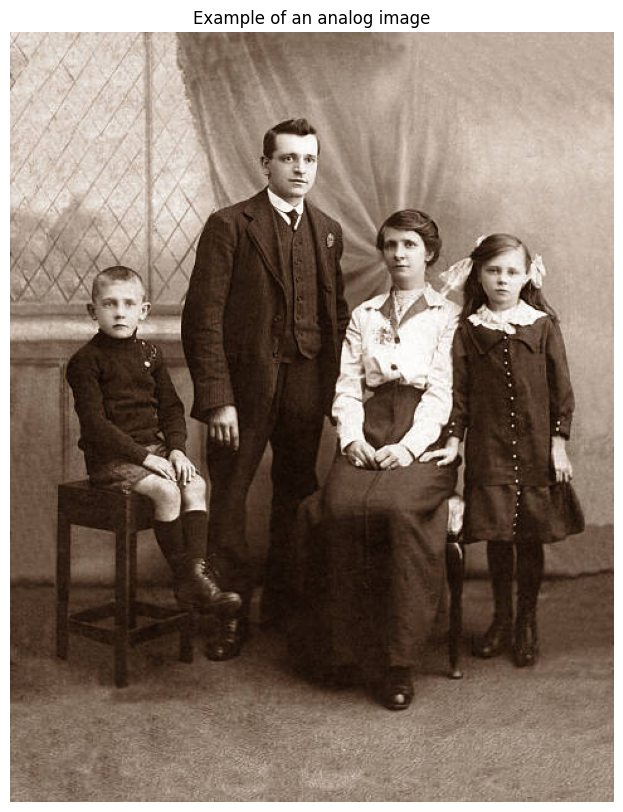

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.image import imread

def show_analog_image(analog_image):
    # load image
    image = imread(analog_image)

    # display the image
    plt.figure(figsize=(15,10))
    plt.imshow(image)
    plt.title('Example of an analog image')
    plt.axis('off')
    plt.show()

# display analog image
show_analog_image('analog_image.jpg')

Load and Display a Digital Image

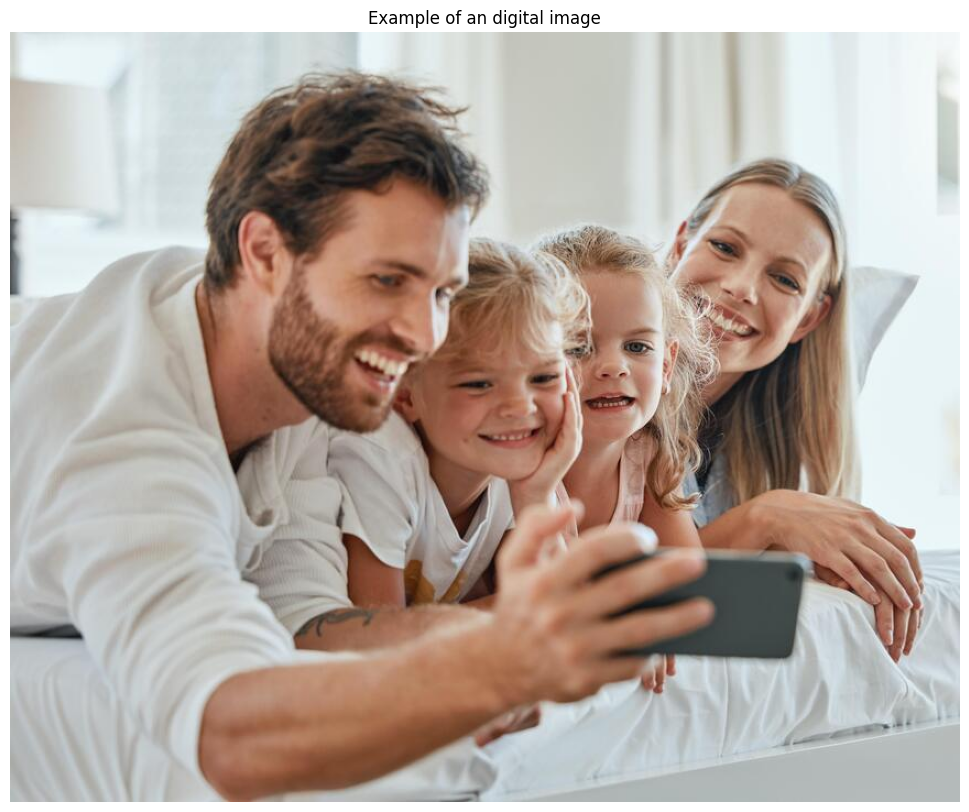

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.image import imread

def show_analog_image(digital_image):
    # load image
    image = imread(digital_image)

    # display the image
    plt.figure(figsize=(15,10))
    plt.imshow(image)
    plt.title('Example of an digital image')
    plt.axis('off')
    plt.show()

# display analog image
show_analog_image('digital_image.jpg')


Up Sampling (Scaling Up) analog image

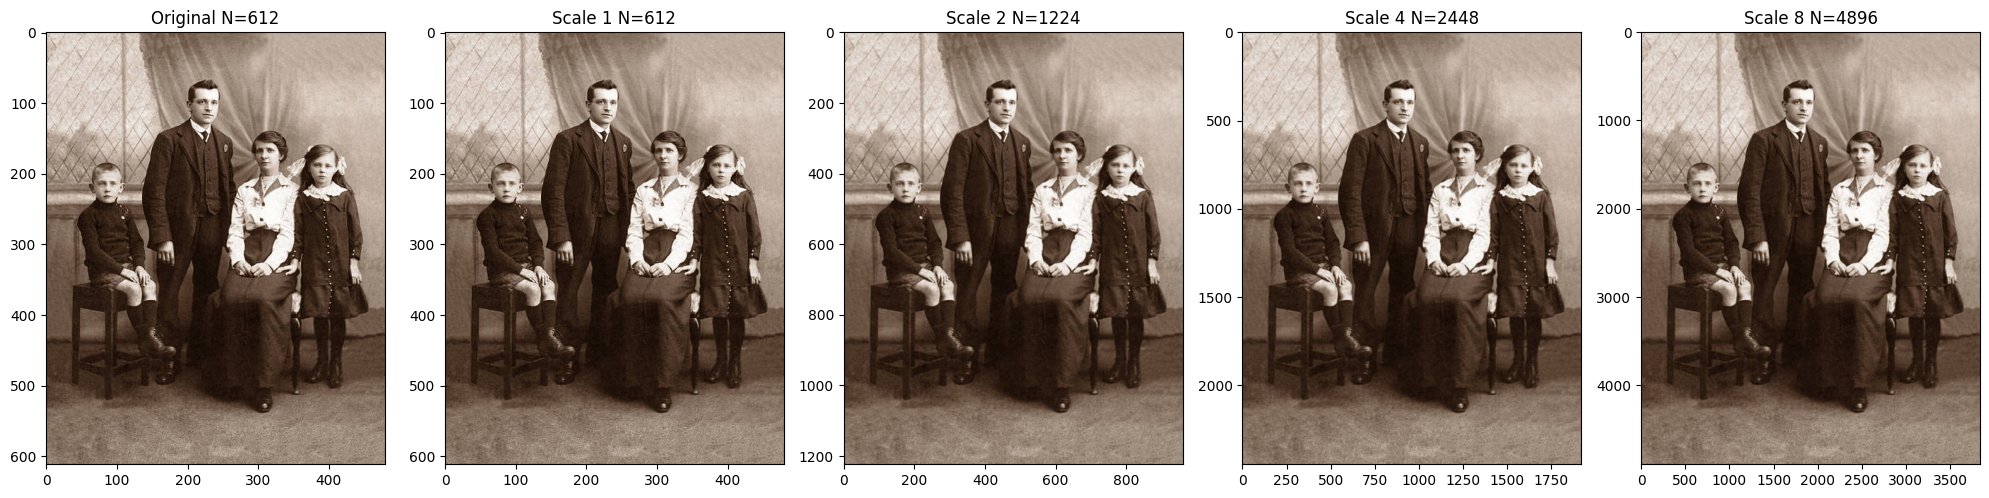

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.image import imread
from skimage.transform import resize

def upsample_image(analog_image):
  # load the original image
  image = imread(analog_image)

  # create upsampled images manually
  # resize image

  # scale 1 -> original size(no enlargement)
  image_1 = resize(
      image,
      (image.shape[0]*1, image.shape[1]*1),
      anti_aliasing=True
  )

  # scale 2 -> image become 2* larger
  image_2 = resize(
      image,
      (image.shape[0]*2, image.shape[1]*2),
      anti_aliasing=True
  )

  # scale 4 -> image become 4* larger
  image_4 = resize(
      image,
      (image.shape[0]*4, image.shape[1]*4),
      anti_aliasing=True
  )

  # scale 8 -> image become 8* larger
  image_8 = resize(
      image,
      (image.shape[0]*8, image.shape[1]*8),
      anti_aliasing=True
  )

  # create plotting area (1 row and 5 columns)
  fig, ax = plt.subplots(1, 5, figsize=(20,10))

  #display image
  #original image
  ax[0].imshow(image)
  ax[0].set_title('Original N=%d' % image.shape[0])

  #scale 01
  ax[1].imshow(image_1)
  ax[1].set_title('Scale 1 N=%d' % image_1.shape[0])

  #scale 02
  ax[2].imshow(image_2)
  ax[2].set_title('Scale 2 N=%d' % image_2.shape[0])

  #scale 04
  ax[3].imshow(image_4)
  ax[3].set_title('Scale 4 N=%d' % image_4.shape[0])

  #scale 08
  ax[4].imshow(image_8)
  ax[4].set_title('Scale 8 N=%d' % image_8.shape[0])

  plt.tight_layout()
  plt.show()

# call the function with the image file
upsample_image("analog_image.jpg")

Down Sampling (Scaling Down) analog image

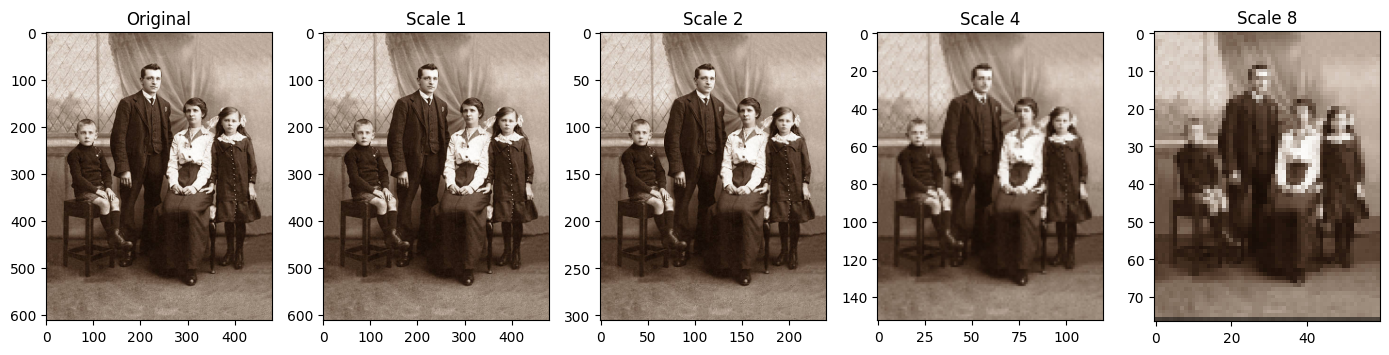

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.image import imread
from skimage.transform import downscale_local_mean

def downsample_image(analog_image):
  # load the original image
  image = imread(analog_image)

  # create upsampled images manually
  # resize image

  # scale 1 -> original size(no enlargement)
  image_1 = downscale_local_mean(image, (1,1,1)).astype(int)

  # scale 2
  image_2 = downscale_local_mean(image, (2,2,1)).astype(int)

  # scale 4
  image_4 = downscale_local_mean(image, (4,4,1)).astype(int)

  # scale 8
  image_8 = downscale_local_mean(image, (8,8,1)).astype(int)

  # create plotting area (1 row and 5 columns)
  fig, ax = plt.subplots(1, 5, figsize=(14,4))

  #display image
  #original image
  ax[0].imshow(image)
  ax[0].set_title('Original')

  #scale 01
  ax[1].imshow(image_1)
  ax[1].set_title('Scale 1')

  #scale 02
  ax[2].imshow(image_2)
  ax[2].set_title('Scale 2')

  #scale 04
  ax[3].imshow(image_4)
  ax[3].set_title('Scale 4')

  #scale 08
  ax[4].imshow(image_8)
  ax[4].set_title('Scale 8')

  plt.tight_layout()
  plt.show()

# call the function with the image file
downsample_image("analog_image.jpg")

Quantization on analog image

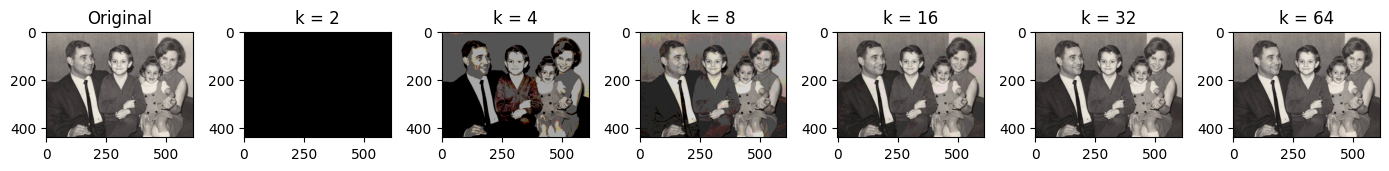

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.image import imread
import numpy as np

def quantize_image(analog_image):
  #load the original image
  image = imread(analog_image)

  #choose the different k values manually
  k1 = 2
  k2 = 4
  k3 = 8
  k4 = 16
  k5 = 32
  k6 = 64

  #create bins for each k values
  #np.linspace this creates evenly spaced values between 0 and max width the given k
  bins1 = np.linspace(0, image.max(), k1)
  bins2 = np.linspace(0, image.max(), k2)
  bins3 = np.linspace(0, image.max(), k3)
  bins4 = np.linspace(0, image.max(), k4)
  bins5 = np.linspace(0, image.max(), k5)
  bins6 = np.linspace(0, image.max(), k6)

  #quantize image
  #np.digitize(): assigns each pixels to the nearest bin
  q1 = np.digitize(image, bins1)
  q2 = np.digitize(image, bins2)
  q3 = np.digitize(image, bins3)
  q4 = np.digitize(image, bins4)
  q5 = np.digitize(image, bins5)
  q6 = np.digitize(image, bins6)

  #reconstruct image
  #covert bin numbers back into intensity values
  r1 = (np.vectorize(bins1.tolist().__getitem__)(q1-1)).astype(int)
  r2 = (np.vectorize(bins2.tolist().__getitem__)(q2-1)).astype(int)
  r3 = (np.vectorize(bins3.tolist().__getitem__)(q3-1)).astype(int)
  r4 = (np.vectorize(bins4.tolist().__getitem__)(q4-1)).astype(int)
  r5 = (np.vectorize(bins5.tolist().__getitem__)(q5-1)).astype(int)
  r6 = (np.vectorize(bins6.tolist().__getitem__)(q6-1)).astype(int)

  # create plotting area (1 row and 7 columns)
  fig, ax = plt.subplots(1, 7, figsize=(14,4))

  #display image
  #original image
  ax[0].imshow(image)
  ax[0].set_title('Original')

  ax[1].imshow(r1)
  ax[1].set_title('k = 2')

  ax[2].imshow(r2)
  ax[2].set_title('k = 4')

  ax[3].imshow(r3)
  ax[3].set_title('k = 8')

  ax[4].imshow(r4)
  ax[4].set_title('k = 16')

  ax[5].imshow(r5)
  ax[5].set_title('k = 32')

  ax[6].imshow(r6)
  ax[6].set_title('k = 64')

  plt.tight_layout()
  plt.show()

# call the function with the image file
quantize_image("analog_image.jpg")


Image conversions

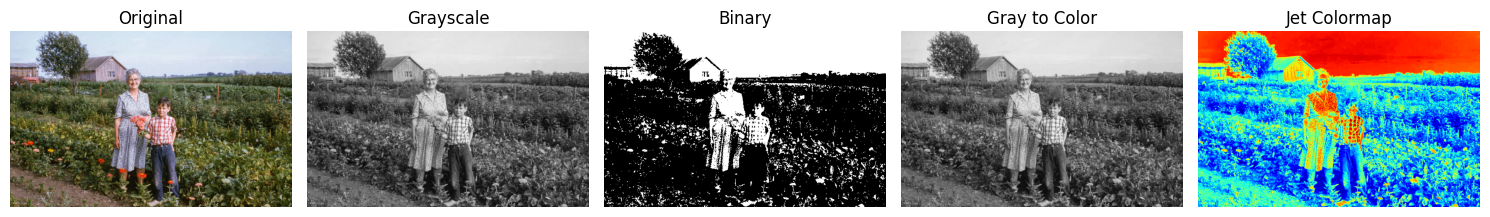

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.image import imread

def show_image_color_types(digital_image):
  #load the original image
  image = imread(digital_image)
  #Convert to grayscale
  gray = rgb2gray(image)

  #Convert grayscale to binary
  binary = img_as_uint(gray > 0.5)

  #Convert grayscale to color (3 channel)
  color = gray2rgb(gray)

  #Apply jet colormap
  jet = plt.cm.jet(gray)

  #display images
  fig, ax = plt.subplots(1,5, figsize=(15,5))

  ax[0].imshow(image)
  ax[0].set_title("Original")

  ax[1].imshow(gray, cmap='gray')
  ax[1].set_title("Grayscale")

  ax[2].imshow(binary, cmap='gray')
  ax[2].set_title("Binary")

  ax[3].imshow(color)
  ax[3].set_title("Gray to Color")

  ax[4].imshow(jet)
  ax[4].set_title("Jet Colormap")

  for a in ax:
      a.axis("off")

  plt.tight_layout()
  plt.show()

# call the function
show_image_color_types("digital_image.jpg")